<a href="https://colab.research.google.com/github/Amulyanrao7777/NLP/blob/main/lab6_vectorization_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 1. Define our corpus
corpus = [
    "I love machine learning.",
    "Machine learning is amazing.",
    "Deep learning and machine learning are related."
]

# 2. Initialize the Vectorizer and transform the text
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(corpus)

# 3. View the results as a DataFrame for readability
vocabulary = vectorizer.get_feature_names_out()
df_bow = pd.DataFrame(bow_matrix.toarray(), columns=vocabulary)
print("Bag of Words Matrix:\n", df_bow)

Bag of Words Matrix:
    amazing  and  are  deep  is  learning  love  machine  related
0        0    0    0     0   0         1     1        1        0
1        1    0    0     0   1         1     0        1        0
2        0    1    1     1   0         2     0        1        1


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# 2. Fit and transform the same corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# 3. View the results
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=vocabulary)
print("TF-IDF Matrix:\n", df_tfidf.round(2))

TF-IDF Matrix:
    amazing   and   are  deep    is  learning  love  machine  related
0     0.00  0.00  0.00  0.00  0.00      0.45  0.77     0.45     0.00
1     0.61  0.00  0.00  0.00  0.61      0.36  0.00     0.36     0.00
2     0.00  0.42  0.42  0.42  0.00      0.49  0.00     0.25     0.42


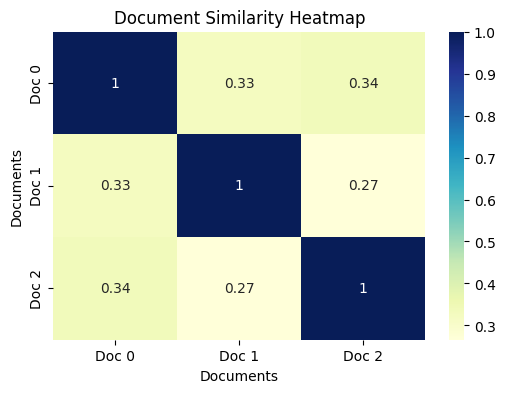

In [3]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the similarity between all documents
similarity_matrix = cosine_similarity(tfidf_matrix)

# 2. Visualize using Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(similarity_matrix, annot=True, cmap='YlGnBu',
            xticklabels=["Doc 0", "Doc 1", "Doc 2"],
            yticklabels=["Doc 0", "Doc 1", "Doc 2"])

plt.title("Document Similarity Heatmap")
plt.xlabel("Documents")
plt.ylabel("Documents")
plt.show()

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Our Database and the User's Query
database = [
    "How to bake a chocolate cake.",
    "A guide to changing your car's oil.",
    "The best chocolate chip cookie recipe."
]
user_query = "chocolate recipes"

# 2. Combine them so the Vectorizer learns the full vocabulary
all_texts = database + [user_query]

# 3. Vectorize using TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(all_texts)

# 4. Separate the query vector from the database vectors
database_vectors = tfidf_matrix[:-1]
query_vector = tfidf_matrix[-1:]

# 5. Calculate similarity between the query and the database
similarities = cosine_similarity(query_vector, database_vectors)

# 6. Find the best match
best_match_idx = similarities.argmax()
print(f"User searched for: '{user_query}'")
print(f"Best matching document: '{database[best_match_idx]}'")
print(f"Similarity Score: {similarities[0, best_match_idx]:.4f}")

User searched for: 'chocolate recipes'
Best matching document: 'How to bake a chocolate cake.'
Similarity Score: 0.1711


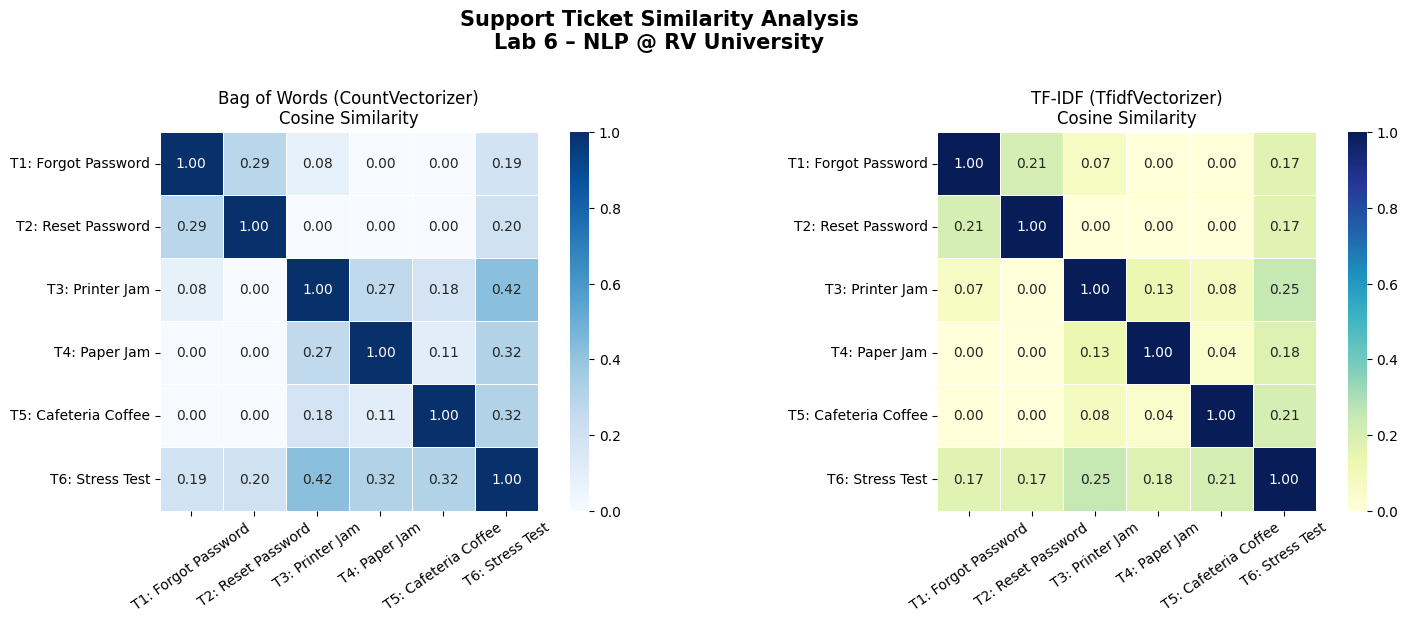


── Stress-Test Ticket (T6) Similarity Scores ──
Ticket                         BoW     TF-IDF
---------------------------------------------
T1: Forgot Password         0.1907     0.1701
T2: Reset Password          0.2000     0.1671
T3: Printer Jam             0.4226     0.2503
T4: Paper Jam               0.3162     0.1822
T5: Cafeteria Coffee        0.3162     0.2094


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ─────────────────────────────────────────────
# 1. DATASET  (5 original + 1 stress-test ticket)
# ─────────────────────────────────────────────
support_tickets = [
    "I forgot my password and cannot log into my account.",
    "Need help resetting my portal password, I keep getting an error.",
    "The printer on the 3rd floor is jammed and making a weird noise.",
    "Paper jam in the main office printer, needs maintenance.",
    "The cafeteria ran out of coffee again, please restock.",
    # Stress-test ticket: mixes keywords from multiple clusters
    "I forgot the password for the cafeteria printer portal.",
]

labels = [
    "T1: Forgot Password",
    "T2: Reset Password",
    "T3: Printer Jam",
    "T4: Paper Jam",
    "T5: Cafeteria Coffee",
    "T6: Stress Test",
]

# ─────────────────────────────────────────────
# 2. VECTORIZATION
# ─────────────────────────────────────────────

# --- Bag of Words ---
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(support_tickets)

# --- TF-IDF ---
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(support_tickets)

# ─────────────────────────────────────────────
# 3. COSINE SIMILARITY MATRICES
# ─────────────────────────────────────────────
bow_sim   = cosine_similarity(bow_matrix)
tfidf_sim = cosine_similarity(tfidf_matrix)

# ─────────────────────────────────────────────
# 4. SIDE-BY-SIDE HEATMAP PLOT
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Support Ticket Similarity Analysis\nLab 6 – NLP @ RV University",
    fontsize=15, fontweight="bold", y=1.02,
)

heatmap_kwargs = dict(
    annot=True, fmt=".2f",
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, linecolor="white",
    square=True,
)

# Bag of Words heatmap
sns.heatmap(bow_sim, ax=axes[0], cmap="Blues", **heatmap_kwargs)
axes[0].set_title("Bag of Words (CountVectorizer)\nCosine Similarity", fontsize=12)
axes[0].tick_params(axis="x", rotation=35)
axes[0].tick_params(axis="y", rotation=0)

# TF-IDF heatmap
sns.heatmap(tfidf_sim, ax=axes[1], cmap="YlGnBu", **heatmap_kwargs)
axes[1].set_title("TF-IDF (TfidfVectorizer)\nCosine Similarity", fontsize=12)
axes[1].tick_params(axis="x", rotation=35)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()
# ─────────────────────────────────────────────
# 5. CONSOLE SUMMARY – Stress-Test Ticket Row
# ─────────────────────────────────────────────
print("\n── Stress-Test Ticket (T6) Similarity Scores ──")
print(f"{'Ticket':<25} {'BoW':>8} {'TF-IDF':>10}")
print("-" * 45)
for i, lbl in enumerate(labels[:-1]):
    print(f"{lbl:<25} {bow_sim[5, i]:>8.4f} {tfidf_sim[5, i]:>10.4f}")

The code worked correctly on the first try. The libraries used (scikit-learn, seaborn, matplotlib) matched exactly what the lab required. No hallucinations or fixes were needed.

####Mathematical Reflection:
The stress-test ticket T6, "I forgot the password for the cafeteria printer portal", scored highest similarity with the Printer Jam cluster (T3), not the Password cluster as one might expect semantically.
This happens because TF-IDF rewards words that are rare globally but frequent locally. The word "printer" appears only in T3 and T4, giving it a high IDF score. So when T6 contains "printer", TF-IDF immediately pulls it toward that cluster. Meanwhile, "password" appears in both T1 and T2, making it slightly less rare, and therefore weighted lower.
TF-IDF has no understanding of meaning, it only sees raw word frequencies and rarity statistics. It cannot tell that the sentence is fundamentally about a login problem. This is why modern NLP uses word embeddings (Word2Vec, BERT) which encode semantic relationships, not just word counts.